# Get measured capacity and resistance for each formation protocol

2025/04/30

Andrew Weng

In [1]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src import plotter as plotter
from src import ioutils as ioutils
from src import simutils as simutils
from scipy.interpolate import interp1d
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

%load_ext autoreload
%matplotlib widget
plotter.initialize(plt)

target_dir = os.getcwd()

# Load the experimental data

In [2]:
expt1, df1 = ioutils.fetch_experimental_data(152064, to_include_cycling=True)
# expt2, df2 = ioutils.fetch_experimental_data(152074)
expt3, df3 = ioutils.fetch_experimental_data(152071, to_include_cycling=True)
expt4, df4 = ioutils.fetch_experimental_data(152098, to_include_cycling=True)

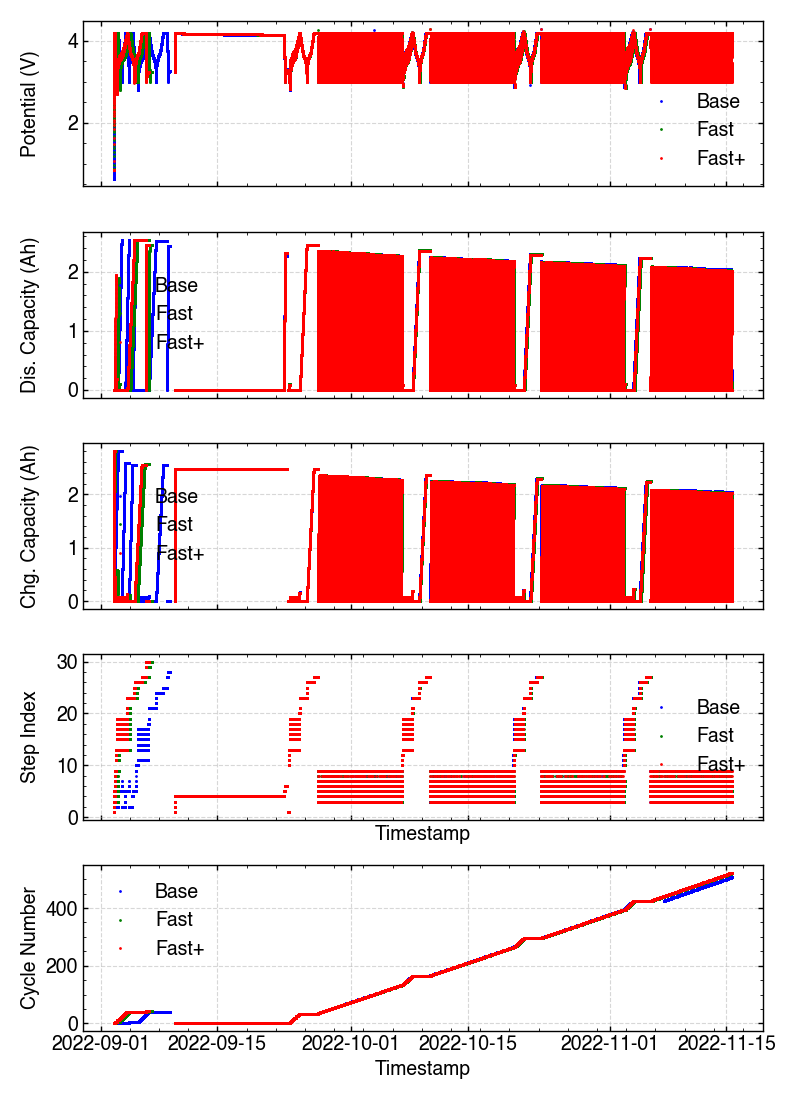

In [3]:
%matplotlib widget

fig, axs = plt.subplots(5, 1, figsize=(8, 11), sharex=True)

xvar = 'Timestamp'
xval1 = df1[xvar]
xval3 = df3[xvar]
xval4 = df4[xvar]

# First subplot
axs[0].plot(xval1, df1['Potential (V)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[0].plot(xval3, df3['Potential (V)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[0].plot(xval4, df4['Potential (V)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[0].set_ylabel('Potential (V)')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend()

# Second subplot
axs[1].plot(xval1, df1['Discharge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[1].plot(xval3, df3['Discharge Capacity (Ah)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[1].plot(xval4, df4['Discharge Capacity (Ah)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[1].set_ylabel('Dis. Capacity (Ah)')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend()

# Third subplot
axs[2].plot(xval1, df1['Charge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[2].plot(xval3, df3['Charge Capacity (Ah)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[2].plot(xval4, df4['Charge Capacity (Ah)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[2].set_ylabel('Chg. Capacity (Ah)')
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].legend()

# Fourth subplot
axs[3].plot(xval1, df1['Step Index'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[3].plot(xval3, df3['Step Index'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[3].plot(xval4, df4['Step Index'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[3].set_ylabel('Step Index')
axs[3].set_xlabel('Timestamp')
axs[3].grid(True, linestyle='--', alpha=0.5)
axs[3].legend()

# Fifth suplot (Cycle Number)
axs[4].plot(xval1, df1['Cycle Number'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[4].plot(xval3, df3['Cycle Number'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[4].plot(xval4, df4['Cycle Number'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[4].legend()
axs[4].set_ylabel('Cycle Number')
axs[4].set_xlabel(xvar)
axs[4].grid(True, linestyle='--', alpha=0.5)

# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.show()

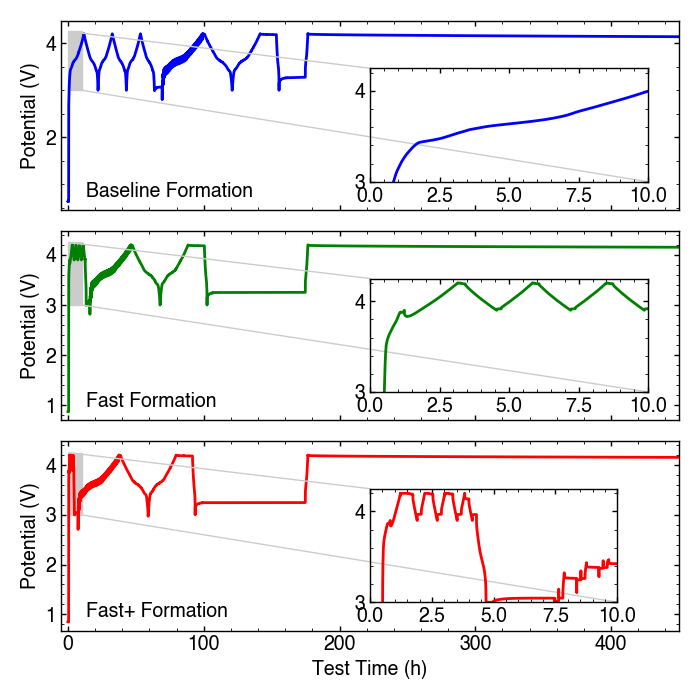

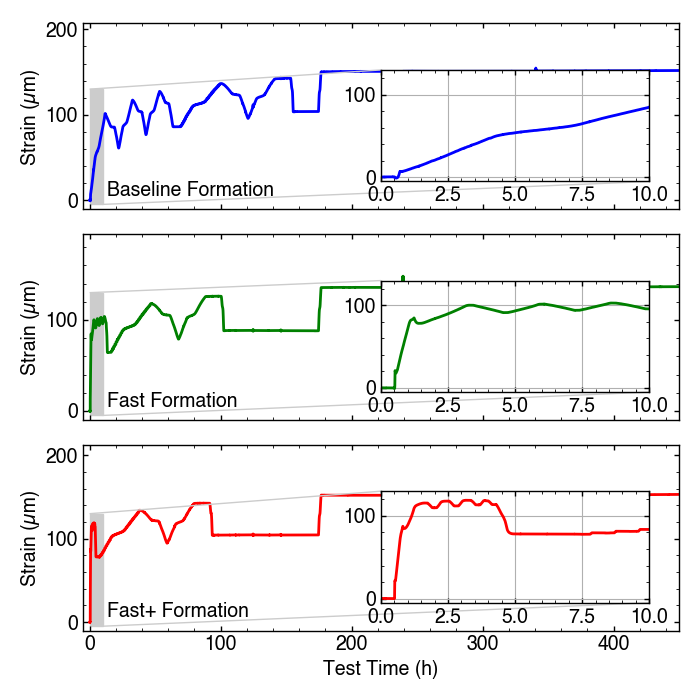

In [4]:
FIGSIZE = (7, 7)
fig, axs = plt.subplots(3, 1, figsize=FIGSIZE, sharex=True)

axs[0].plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], label='Baseline Formation', color='blue', ls='-')
axs[0].set_ylabel('Potential (V)')
axs[0].grid(False)
axs[0].text(0.04, 0.05, "Baseline Formation", transform=axs[0].transAxes, fontsize=14, va='bottom', ha='left')

axs[1].plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], label='Fast Formation', color='green', ls='-')
axs[1].set_ylabel('Potential (V)')
axs[1].grid(False)
axs[1].text(0.04, 0.05, "Fast Formation", transform=axs[1].transAxes, fontsize=14, va='bottom', ha='left')

axs[2].plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], label='Fast+ Formation', color='red', ls='-')
axs[2].set_ylabel('Potential (V)')
axs[2].grid(False)
axs[2].set_xlim((-5, 450))
axs[2].text(0.04, 0.05, "Fast+ Formation", transform=axs[2].transAxes, fontsize=14, va='bottom', ha='left')

# Create insets for each subplot
axins1 = axs[0].inset_axes([0.50, 0.15, 0.45, 0.6])
axins2 = axs[1].inset_axes([0.50, 0.15, 0.45, 0.6])
axins3 = axs[2].inset_axes([0.50, 0.15, 0.4, 0.6])

# Plot the zoomed regions
axins1.plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='blue')
axins2.plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='green')
axins3.plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='red')

# Set the limits for the zoomed region (first 10 hours)
for axins in [axins1, axins2, axins3]:
    axins.set_xlim(0, 10)
    axins.set_ylim(3, 4.25)
    axins.grid(False)

# Mark the inset regions
mark_inset(axs[0], axins1, loc1=2, loc2=4, fc="0.8", ec="0.8")
mark_inset(axs[1], axins2, loc1=2, loc2=4, fc="0.8", ec="0.8")
mark_inset(axs[2], axins3, loc1=2, loc2=4, fc="0.8", ec="0.8")

axs[2].set_xlabel('Test Time (h)')
# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.savefig('experimental_voltage.svg', format='svg', dpi=300)
plt.show()

fig, axs = plt.subplots(3, 1, figsize=FIGSIZE, sharex=True)

axs[0].plot(expt1['daq_time']/3600, expt1['daq_strain'], label='Baseline formation', color='blue', ls='-', marker='', markersize=1)
axs[0].set_ylabel('Strain (µm)')
axs[0].grid(False)
axs[0].text(0.04, 0.05, "Baseline Formation", transform=axs[0].transAxes, fontsize=14, va='bottom', ha='left')

axs[1].plot(expt3['daq_time']/3600, expt3['daq_strain'], label='Fast Formation', color='green', ls='-', marker='', markersize=1)
axs[1].set_ylabel('Strain (µm)')
axs[1].grid(False)
axs[1].text(0.04, 0.05, "Fast Formation", transform=axs[1].transAxes, fontsize=14, va='bottom', ha='left')

axs[2].plot(expt4['daq_time']/3600, expt4['daq_strain'], label='Fast+ Formation', color='red', ls='-', marker='', markersize=1)
axs[2].set_ylabel('Strain (µm)')
axs[2].grid(False)
axs[2].set_xlim((-5, 450))
axs[2].text(0.04, 0.05, "Fast+ Formation", transform=axs[2].transAxes, fontsize=14, va='bottom', ha='left')

# Create insets for each subplot
axins1 = axs[0].inset_axes([0.50, 0.15, 0.45, 0.6])
axins2 = axs[1].inset_axes([0.50, 0.15, 0.45, 0.6])
axins3 = axs[2].inset_axes([0.50, 0.15, 0.45, 0.6])

# Plot the zoomed regions
axins1.plot(expt1['daq_time']/3600, expt1['daq_strain'], color='blue')
axins2.plot(expt3['daq_time']/3600, expt3['daq_strain'], color='green')
axins3.plot(expt4['daq_time']/3600, expt4['daq_strain'], color='red')

# Set the limits for the zoomed region (first 10 hours)
for axins in [axins1, axins2, axins3]:
    axins.set_xlim(0, 10)
    axins.set_ylim(-5, 130)
    axins.grid(True)

# Mark the inset regions
mark_inset(axs[0], axins1, loc1=2, loc2=4, fc="0.8", ec="0.8")
mark_inset(axs[1], axins2, loc1=2, loc2=4, fc="0.8", ec="0.8")
mark_inset(axs[2], axins3, loc1=2, loc2=4, fc="0.8", ec="0.8")

# axs[1].plot(expt1['daq_time']/3600, expt1['daq_strain'], label='Base', color='blue', ls='', marker='o', markersize=1)
# axs[1].plot(expt3['daq_time']/3600, expt3['daq_strain'], label='Fast', color='green', ls='', marker='o', markersize=1)
# axs[1].plot(expt4['daq_time']/3600, expt4['daq_strain'], label='Fast+', color='red', ls='', marker='o', markersize=1)
# axs[1].set_ylabel('Strain (um)')
# axs[1].legend()

axs[2].set_xlabel('Test Time (h)')
# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.savefig('experimental_strain.svg', format='svg', dpi=300)
plt.show()

In [5]:
# With optimal d_ec and d_vc values
d_ec_opt1 = 3.2e-20  # Optimal d_ec for base
d_ec_opt2 = 3.2e-20  # Optimal d_ec for fast
d_ec_opt3 = 5.1e-20  # Optimal d_ec for fast+
d_vc_opt1 = 4.2e-16  # Optimal d_vc for base
d_vc_opt2 = 3.2e-17  # Optimal d_vc for fast
d_vc_opt3 = 3.2e-17  # Optimal d_vc for fast+
d_ec_b = 4.2e-20  # Baseline d_ec from Weng2023
d_vc_b = 6.6e-18  # Baseline d_vc from Weng2023

# d_ec_opt = 2.84e-20
# d_vc_opt = 5.39e-14
# gamma_kappa = 3367 * 2
# d_vc_opt = 6.14664e-14
# d_ec_opt = 4.5185e-20


In [6]:
# df_sim1 = run_sim('base', d_ec_opt, d_vc_opt, gamma_kappa, dt=dt_data_interp, to_follow_current=True, current_vec=i_interp1)
# df_sim2 = run_sim('fast', d_ec_opt, d_vc_opt, gamma_kappa, dt=dt_data_interp, to_follow_current=True, current_vec=i_interp3)
# df_sim3 = run_sim('fast+', d_ec_opt, d_vc_opt, gamma_kappa, dt=dt_data_interp, to_follow_current=True, current_vec=i_interp4)

df_sim1o = simutils.run_sim('base', d_ec_opt1, d_vc_opt1, dt=5, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=True)
df_sim2o = simutils.run_sim('fast', d_ec_opt2, d_vc_opt2, dt=5, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=True)
df_sim3o = simutils.run_sim('fast+', d_ec_opt3, d_vc_opt3, dt=1, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=True)

# With baseline d_ec and d_vc values from Weng2023
df_sim1 = simutils.run_sim('base', d_ec_b, d_vc_b, dt=5, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=True)
df_sim2 = simutils.run_sim('fast', d_ec_b, d_vc_b, dt=5, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=True)
df_sim3 = simutils.run_sim('fast+', d_ec_b, d_vc_b, dt=1, to_follow_current=False, to_simulate_form_aging=True, to_simulate_cycling=True)

# With baseline d_ec and d_vc values from the recent parameter sensitivity study (it yielded some different values because we 
# explicitly ran search for the optimal values instead of "eyeballing it" as we did for Weng2023; it makes a big difference in some metrics 
# like VC concentration; it makes less of a difference for other metrics like voltage fit).
# df_sim1 = simutils.run_sim('base', 3.2e-20, 4.2e-16, gamma_kappa, dt=5, to_follow_current=False, to_simulate_form_aging=True)
# df_sim2 = simutils.run_sim('fast', 3.2e-20, 4.2e-16, gamma_kappa, dt=5, to_follow_current=False, to_simulate_form_aging=True)
# df_sim3 = simutils.run_sim('fast+', 3.2e-20, 4.2e-16, gamma_kappa, dt=1, to_follow_current=False, to_simulate_form_aging=True)



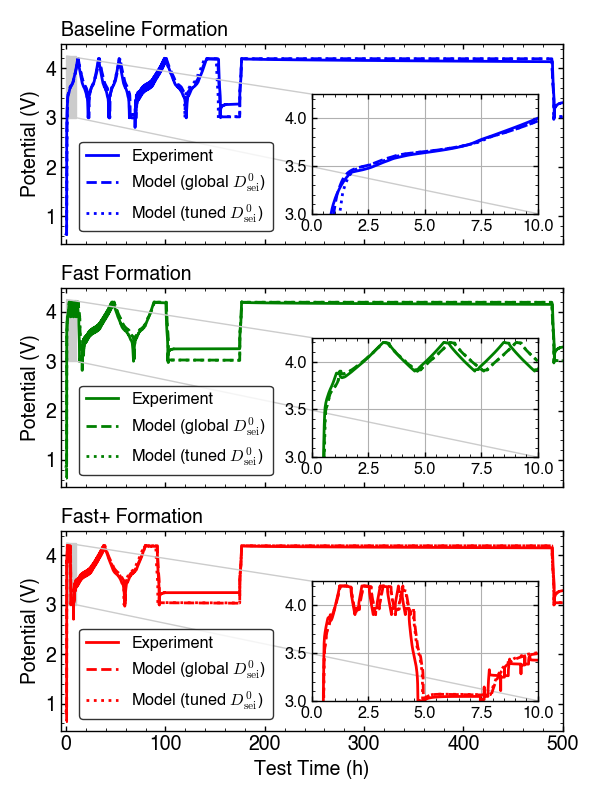

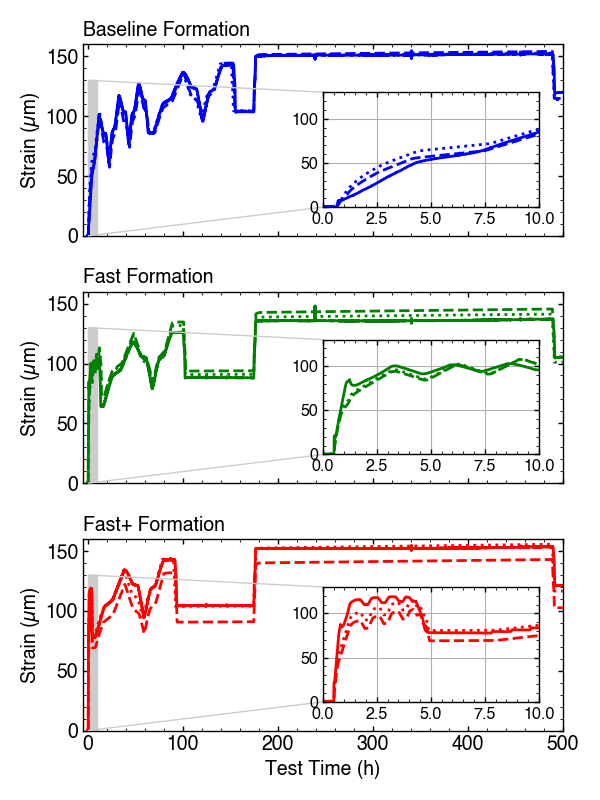

In [7]:
%matplotlib widget 

INCLUDE_INSET = True

ZOOM = 1
match ZOOM:
    case 1:
        XLIM_INSET = (0, 10)
        XMAX = 500
        STRAIN_LIM = (0, 160)
        STRAIN_LIM_INSET = (0, 130)
    case 2:        
        XLIM_INSET = (550, 650)
        XMAX = 800
        STRAIN_LIM = (0, 310)
        STRAIN_LIM_INSET = (100, 285)

FIGSIZE = (6, 8)

## VOLTAGE PLOTS
fig, axs = plt.subplots(3, 1, figsize=FIGSIZE, sharex=True, sharey=True)

axs[0].plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], label='Experiment', color='blue', ls='-')
axs[0].plot(df_sim1['t']/3600, df_sim1['vt'], label=r'Model (global $D_{\mathrm{sei}}^0$)', color='blue', ls='--')
axs[0].plot(df_sim1o['t']/3600, df_sim1o['vt'], label=r'Model (tuned $D_{\mathrm{sei}}^0$)', color='blue', ls=':')
axs[0].set_ylabel('Potential (V)')
axs[0].grid(False)
axs[0].set_title('Baseline Formation', loc='left', fontsize='medium')
# axs[0].text(0.04, 0.05, "Baseline Formation", transform=axs[0].transAxes, fontsize=14, va='bottom', ha='left')
axs[0].legend(loc='lower left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black', bbox_to_anchor=(0.02, 0.02))

axs[1].plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], label='Experiment', color='green', ls='-')
axs[1].plot(df_sim2['t']/3600, df_sim2['vt'], label=r'Model (global $D_{\mathrm{sei}}^0$)', color='green', ls='--')
axs[1].plot(df_sim2o['t']/3600, df_sim2o['vt'], label=r'Model (tuned $D_{\mathrm{sei}}^0$)', color='green', ls=':')
axs[1].set_ylabel('Potential (V)')
axs[1].grid(False)
axs[1].set_title('Fast Formation', loc='left', fontsize='medium')
# axs[1].text(0.04, 0.05, "Fast Formation", transform=axs[1].transAxes, fontsize=14, va='bottom', ha='left')
axs[1].legend(loc='lower left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black', bbox_to_anchor=(0.02, 0.02))

axs[2].plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], label='Experiment', color='red', ls='-')
axs[2].plot(df_sim3['t']/3600, df_sim3['vt'], label=r'Model (global $D_{\mathrm{sei}}^0$)', color='red', ls='--')
axs[2].plot(df_sim3o['t']/3600, df_sim3o['vt'], label=r'Model (tuned $D_{\mathrm{sei}}^0$)', color='red', ls=':')
axs[2].legend(loc='lower left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black', bbox_to_anchor=(0.02, 0.02))
axs[2].set_ylabel('Potential (V)')
axs[2].grid(False)
axs[2].set_xlim(-5, XMAX)
axs[2].set_title('Fast+ Formation', loc='left', fontsize='medium')
# axs[2].text(0.04, 0.05, "Fast+ Formation", transform=axs[2].transAxes, fontsize=14, va='bottom', ha='left')

if INCLUDE_INSET:
    # Create insets for each subplot
    axins1 = axs[0].inset_axes([0.50, 0.15, 0.45, 0.6])
    axins2 = axs[1].inset_axes([0.50, 0.15, 0.45, 0.6])
    axins3 = axs[2].inset_axes([0.50, 0.15, 0.45, 0.6])

    # Plot the zoomed regions
    axins1.plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='blue')
    axins1.plot(df_sim1['t']/3600, df_sim1['vt'], color='blue', ls='--')
    axins1.plot(df_sim1o['t']/3600, df_sim1o['vt'], color='blue', ls=':')
    axins2.plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='green')
    axins2.plot(df_sim2['t']/3600, df_sim2['vt'], color='green', ls='--')
    axins2.plot(df_sim2o['t']/3600, df_sim2o['vt'], color='green', ls=':')
    axins3.plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='red')
    axins3.plot(df_sim3['t']/3600, df_sim3['vt'], color='red', ls='--')
    axins3.plot(df_sim3o['t']/3600, df_sim3o['vt'], color='red', ls=':')

    # Set the limits for the zoomed region (first 10 hours)
    for axins in [axins1, axins2, axins3]:
        axins.set_xlim(XLIM_INSET)
        axins.set_ylim(3, 4.25)
        axins.tick_params(axis='both', labelsize='small')
        # axins.grid(False)

    # Mark the inset regions
    mark_inset(axs[0], axins1, loc1=2, loc2=4, fc="0.8", ec="0.8")
    mark_inset(axs[1], axins2, loc1=2, loc2=4, fc="0.8", ec="0.8")
    mark_inset(axs[2], axins3, loc1=2, loc2=4, fc="0.8", ec="0.8")

axs[2].set_xlabel('Test Time (h)')
# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.savefig(f'experimental_voltage_{XMAX}h.svg', format='svg', dpi=300)
plt.show()


## STRAIN PLOTS
fig, axs = plt.subplots(3, 1, figsize=FIGSIZE, sharex=True, sharey=True)

axs[0].plot(expt1['daq_time']/3600, expt1['daq_strain'], label='Experiment', color='blue', ls='-', marker='', markersize=1)
axs[0].plot(df_sim1['t']/3600, df_sim1['expansion']*1e6, label=r'Model (global $D_{\mathrm{sei}}^0$)', color='blue', ls='--')
axs[0].plot(df_sim1o['t']/3600, df_sim1o['expansion']*1e6, label=r'Model (tuned $D_{\mathrm{sei}}^0$)', color='blue', ls=':')
axs[0].set_ylabel('Strain (µm)')
axs[0].grid(False)
# axs[0].text(0.04, 0.05, "Baseline Formation", transform=axs[0].transAxes, fontsize=14, va='bottom', ha='left')
axs[0].set_title('Baseline Formation', loc='left', fontsize='medium')
# axs[0].legend(loc='upper left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')
# axs[0].legend(loc='lower left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black', bbox_to_anchor=(0.06, 0.02))

axs[1].plot(expt3['daq_time']/3600, expt3['daq_strain'], label='Experiment', color='green', ls='-', marker='', markersize=1)
axs[1].plot(df_sim2['t']/3600, df_sim2['expansion']*1e6, label=r'Model (global $D_{\mathrm{sei}}^0$)', color='green', ls='--')
axs[1].plot(df_sim2o['t']/3600, df_sim2o['expansion']*1e6, label=r'Model (tuned $D_{\mathrm{sei}}^0$)', color='green', ls=':')
axs[1].set_ylabel('Strain (µm)')
axs[1].grid(False)
# axs[1].text(0.04, 0.05, "Fast Formation", transform=axs[1].transAxes, fontsize=14, va='bottom', ha='left')
axs[1].set_title('Fast Formation', loc='left', fontsize='medium')
# axs[1].legend(loc='upper left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')
# axs[1].legend(loc='lower left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black', bbox_to_anchor=(0.06, 0.02))

axs[2].plot(expt4['daq_time']/3600, expt4['daq_strain'], label='Experiment', color='red', ls='-', marker='', markersize=1)
axs[2].plot(df_sim3['t']/3600, df_sim3['expansion']*1e6, label=r'Model (global $D_{\mathrm{sei}}^0$)', color='red', ls='--')
axs[2].plot(df_sim3o['t']/3600, df_sim3o['expansion']*1e6, label=r'Model (tuned $D_{\mathrm{sei}}^0$)', color='red', ls=':')
axs[2].set_ylabel('Strain (µm)')
axs[2].set_ylim(STRAIN_LIM)
axs[2].grid(False)
axs[2].set_xlim((-5, XMAX))
# axs[2].text(0.04, 0.05, "Fast+ Formation", transform=axs[2].transAxes, fontsize=14, va='bottom', ha='left')
axs[2].set_title('Fast+ Formation', loc='left', fontsize='medium')
# axs[2].legend(loc='upper left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')
# axs[2].legend(loc='lower left', fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black', bbox_to_anchor=(0.06, 0.02))

if INCLUDE_INSET:
    # Create insets for each subplot
    axins1 = axs[0].inset_axes([0.50, 0.15, 0.45, 0.6])
    axins2 = axs[1].inset_axes([0.50, 0.15, 0.45, 0.6])
    axins3 = axs[2].inset_axes([0.50, 0.15, 0.45, 0.6])

    # Plot the zoomed regions
    axins1.plot(expt1['daq_time']/3600, expt1['daq_strain'], color='blue')
    axins1.plot(df_sim1['t']/3600, df_sim1['expansion']*1e6, color='blue', ls='--')
    axins1.plot(df_sim1o['t']/3600, df_sim1o['expansion']*1e6, color='blue', ls=':')
    axins2.plot(expt3['daq_time']/3600, expt3['daq_strain'], color='green')
    axins2.plot(df_sim2['t']/3600, df_sim2['expansion']*1e6, color='green', ls='--')
    axins2.plot(df_sim2o['t']/3600, df_sim2o['expansion']*1e6, color='green', ls=':')
    axins3.plot(expt4['daq_time']/3600, expt4['daq_strain'], color='red')
    axins3.plot(df_sim3['t']/3600, df_sim3['expansion']*1e6, color='red', ls='--')
    axins3.plot(df_sim3o['t']/3600, df_sim3o['expansion']*1e6, color='red', ls=':')

    # Set the limits for the zoomed region (first 10 hours)
    for axins in [axins1, axins2, axins3]:
        axins.set_xlim(XLIM_INSET)
        # axins.set_ylim(-5, 130)
        axins.tick_params(axis='both', labelsize='small')
        axins.set_ylim(STRAIN_LIM_INSET)
        axins.grid(True)

    # Mark the inset regions
    mark_inset(axs[0], axins1, loc1=2, loc2=3, fc="0.8", ec="0.8")
    mark_inset(axs[1], axins2, loc1=2, loc2=3, fc="0.8", ec="0.8")
    mark_inset(axs[2], axins3, loc1=2, loc2=3, fc="0.8", ec="0.8")

# axs[1].plot(expt1['daq_time']/3600, expt1['daq_strain'], label='Base', color='blue', ls='', marker='o', markersize=1)
# axs[1].plot(expt3['daq_time']/3600, expt3['daq_strain'], label='Fast', color='green', ls='', marker='o', markersize=1)
# axs[1].plot(expt4['daq_time']/3600, expt4['daq_strain'], label='Fast+', color='red', ls='', marker='o', markersize=1)
# axs[1].set_ylabel('Strain (um)')
# axs[1].legend()

axs[2].set_xlabel('Test Time (h)')
# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.savefig(f'experimental_strain_{XMAX}h.svg', format='svg', dpi=300)
plt.show()

# ## CURRENT PLOTS

# fig, axs = plt.subplots(3, 1, figsize=FIGSIZE, sharex=True)

# axs[0].plot(expt1['arbin_time']/3600, expt1['arbin_current'], label='Baseline Formation', color='blue', ls='-')
# axs[0].plot(df_sim1['t']/3600, df_sim1['i_app'], label='Simulated', color='blue', ls='--')
# axs[0].set_ylabel('Current (A)')
# axs[0].grid(False)
# axs[0].text(0.04, 0.05, "Baseline Formation", transform=axs[0].transAxes, fontsize=14, va='bottom', ha='left')

# axs[1].plot(expt3['arbin_time']/3600, expt3['arbin_current'], label='Fast Formation', color='green', ls='-')
# axs[1].plot(df_sim2['t']/3600, df_sim2['i_app'], label='Simulated', color='green', ls='--')
# axs[1].set_ylabel('Current (A)')
# axs[1].grid(False)
# axs[1].text(0.04, 0.05, "Fast Formation", transform=axs[1].transAxes, fontsize=14, va='bottom', ha='left')

# axs[2].plot(expt4['arbin_time']/3600, expt4['arbin_current'], label='Fast+ Formation', color='red', ls='-')
# axs[2].plot(df_sim3['t']/3600, df_sim3['i_app'], label='Simulated', color='red', ls='--')
# axs[2].set_ylabel('Current (A)')
# axs[2].grid(False)
# axs[2].set_xlim((-5, XMAX))
# axs[2].text(0.04, 0.05, "Fast+ Formation", transform=axs[2].transAxes, fontsize=14, va='bottom', ha='left')

# axs[2].set_xlabel('Test Time (h)')


# if INCLUDE_INSET:
#     # Create insets for each subplot
#     axins1 = axs[0].inset_axes([0.50, 0.15, 0.45, 0.6])
#     axins2 = axs[1].inset_axes([0.50, 0.15, 0.45, 0.6])
#     axins3 = axs[2].inset_axes([0.50, 0.15, 0.45, 0.6])

#     # Plot the zoomed regions
#     axins1.plot(expt1['arbin_time']/3600, expt1['arbin_current'], color='blue')
#     axins1.plot(df_sim1['t']/3600, df_sim1['i_app'], color='blue', ls='--')
#     axins2.plot(expt3['arbin_time']/3600, expt3['arbin_current'], color='green')
#     axins2.plot(df_sim2['t']/3600, df_sim2['i_app'], color='green', ls='--')
#     axins3.plot(expt4['arbin_time']/3600, expt4['arbin_current'], color='red')
#     axins3.plot(df_sim3['t']/3600, df_sim3['i_app'], color='red', ls='--')

#     # Set the limits for the zoomed region (first 10 hours)
#     for axins in [axins1, axins2, axins3]:
#         axins.set_xlim(XLIM_INSET)
#         axins.grid(True)

# fig.align_ylabels(axs)
# plt.tight_layout()
# plt.savefig('experimental_current.svg', format='svg', dpi=300)
# plt.show()



# Overlay of all 3 formation protocols

In [8]:
# Set some constants
rho_vc = 1.3
rho_ec = 1.6

In [9]:
df_sim1 = df_sim1o
df_sim2 = df_sim2o
df_sim3 = df_sim3o

<>:187: SyntaxWarning: invalid escape sequence '\m'
<>:187: SyntaxWarning: invalid escape sequence '\m'
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_67573/2196246161.py:187: SyntaxWarning: invalid escape sequence '\m'
  axs[2,0].set_ylabel('$c^0_{\mathrm{VC}}$ (mol/m$^3$)')
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_67573/2196246161.py:250: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


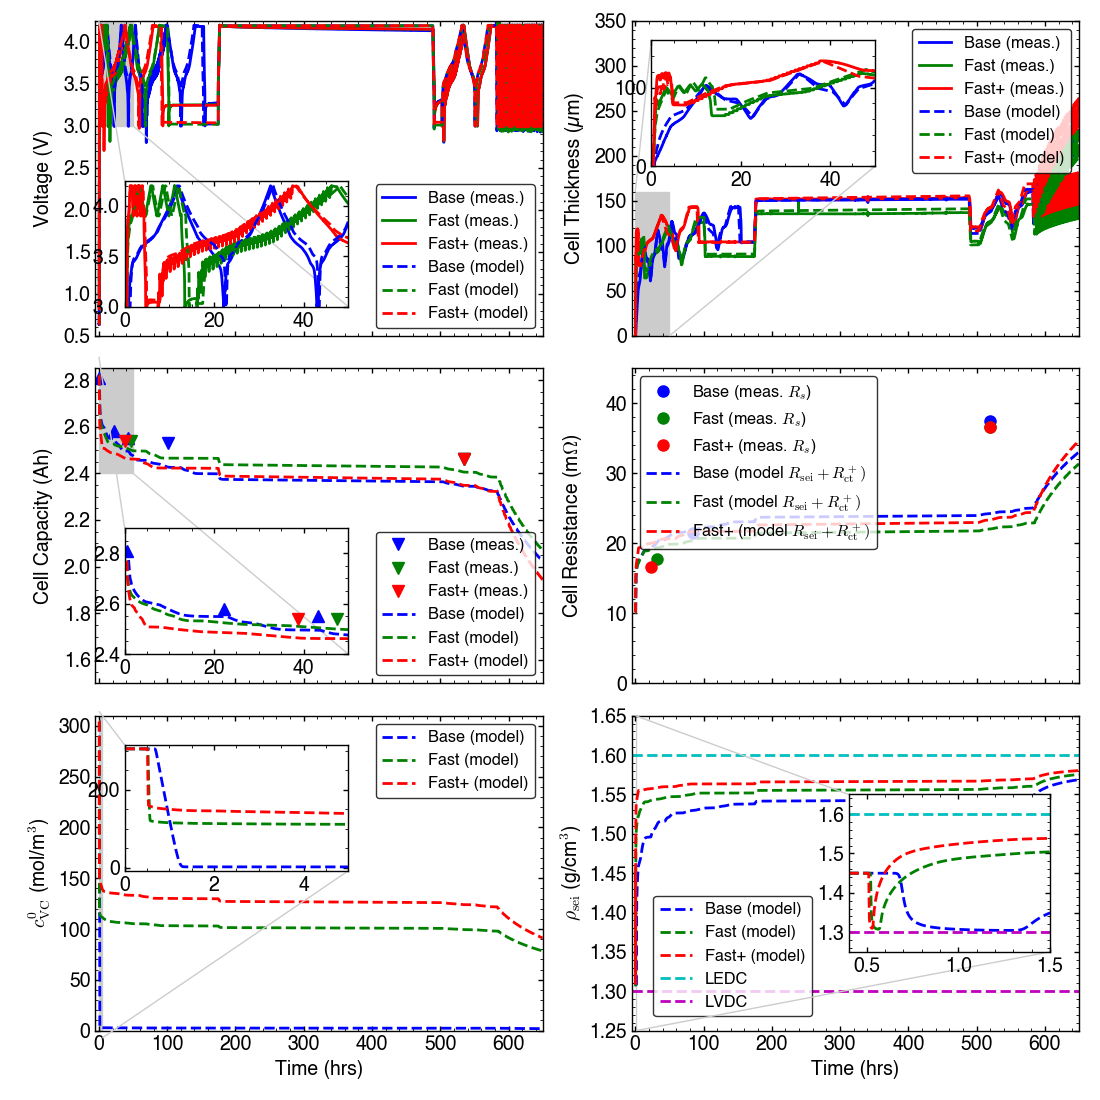

In [10]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

XMAX = 650;

fig, axs = plt.subplots(3, 2, figsize=(11,11), sharex=True)

# First subplot - Voltage
axs[0,0].plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='b', label='Base (meas.)')
axs[0,0].plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='g', label='Fast (meas.)')
axs[0,0].plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='r', label='Fast+ (meas.)')
axs[0,0].plot(df_sim1['t']/3600, df_sim1['vt'], color='b', ls='--', label='Base (model)')
axs[0,0].plot(df_sim2['t']/3600, df_sim2['vt'], color='g', ls='--', label='Fast (model)')
axs[0,0].plot(df_sim3['t']/3600, df_sim3['vt'], color='r', ls='--', label='Fast+ (model)')
axs[0,0].legend(loc='lower right', ncols=1, fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')
axs[0,0].set_ylabel('Voltage (V)')
axs[0,0].grid(False)
axs[0,0].set_ylim(0.5, 4.25)

# Create inset axis for axs[0]
axins = inset_axes(axs[0,0], width="50%", height="40%", loc='lower left', borderpad=1.5)

# Plot the same voltage data in the inset
axins.plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='b')
axins.plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='g')
axins.plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='r')
axins.plot(df_sim1['t']/3600, df_sim1['vt'], color='b', ls='--')
axins.plot(df_sim2['t']/3600, df_sim2['vt'], color='g', ls='--')
axins.plot(df_sim3['t']/3600, df_sim3['vt'], color='r', ls='--')

# Set x and y limits for the zoomed region (first 50 hours)
axins.set_xlim(0, 50)
axins.set_ylim((3.0, 4.25))
axins.grid(False)

# Mark the region on the main plot
mark_inset(axs[0,0], axins, loc1=2, loc2=4, fc="0.8", ec="0.8")

axs[0,1].plot(expt1['daq_time']/3600, expt1['daq_strain'], color='b', label='Base (meas.)', ls='-')
axs[0,1].plot(expt3['daq_time']/3600, expt3['daq_strain'], color='g', label='Fast (meas.)', ls='-')
axs[0,1].plot(expt4['daq_time']/3600, expt4['daq_strain'], color='r', label='Fast+ (meas.)', ls='-')
axs[0,1].plot(df_sim1['t']/3600, df_sim1['expansion']*1e6, color='b', label='Base (model)', ls='--')
axs[0,1].plot(df_sim2['t']/3600, df_sim2['expansion']*1e6, color='g', label='Fast (model)', ls='--')
axs[0,1].plot(df_sim3['t']/3600, df_sim3['expansion']*1e6, color='r', label='Fast+ (model)', ls='--')
axs[0,1].set_ylabel(r'Cell Thickness (µm)')
axs[0,1].set_ylim(bottom=0)
axs[0,1].legend(loc='upper right', ncols=1, fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')
axs[0,1].grid(False)
axs[0,1].set_ylim(0, 350)

# Create inset axis for axs[1]
axins1 = inset_axes(axs[0,1], width="50%", height="40%", loc='upper left', borderpad=1.0)

# Plot the same strain data in the inset
axins1.plot(expt1['daq_time']/3600, expt1['daq_strain'], color='b')
axins1.plot(df_sim1['t']/3600, df_sim1['expansion']*1e6, color='b', ls='--')
axins1.plot(expt3['daq_time']/3600, expt3['daq_strain'], color='g')
axins1.plot(df_sim2['t']/3600, df_sim2['expansion']*1e6, color='g', ls='--')
axins1.plot(expt4['daq_time']/3600, expt4['daq_strain'], color='r')
axins1.plot(df_sim3['t']/3600, df_sim3['expansion']*1e6, color='r', ls='--')

# Set x and y limits for the zoomed region (first 50 hours)
axins1.set_xlim(0, 50)
axins1.set_ylim((0, 160))
axins1.grid(False)

# Mark the region on the main plot
mark_inset(axs[0,1], axins1, loc1=2, loc2=4, fc="0.8", ec="0.8")
# Capacity plots

# Manually extracted capacity values from the experimental data
# During the formation cycling
qc_base_1_time = 0.53*3600 
qc_base_1_val  = 2.81
qc_base_2_time = 22.3*3600
qc_base_2_val  = 2.58
qc_base_3_time = 43.2*3600
qc_base_3_val  = 2.55

qd_base_1_time = 11.9*3600 
qd_base_1_val  = 2.546
qd_base_2_time = 32.8*3600
qd_base_2_val  = 2.545
qd_base_3_time = 53.6*3600
qd_base_3_val  = 2.530

# RPT after formation cycling
qd_base_rpt1_time = 100.6 * 3600
qd_base_rpt1_val  = 2.53
qd_fast_rpt1_time = 47.5 * 3600
qd_fast_rpt1_val  = 2.54
qd_fastp_rpt1_time = 38.7 * 3600
qd_fastp_rpt1_val  = 2.54

# RPT after formation aging
qd_base_rpt2_time = 534.8 * 3600
qd_base_rpt2_val  = 2.46
qd_fast_rpt2_time = 534.8 * 3600
qd_fast_rpt2_val  = 2.46
qd_fastp_rpt2_time = 534.8 * 3600
qd_fastp_rpt2_val  = 2.46

axs[1,0].plot(qc_base_1_time/3600, qc_base_1_val, 'b^', markersize=8, label='')
axs[1,0].plot(qc_base_2_time/3600, qc_base_2_val, 'b^', markersize=8, label='')
axs[1,0].plot(qc_base_3_time/3600, qc_base_3_val, 'b^', markersize=8, label='')
# axs[2].plot(qd_base_1_time/3600, qd_base_1_val, 'kv', markersize=8, label='Base (experiment)')
# axs[2].plot(qd_base_2_time/3600, qd_base_2_val, 'kv', markersize=8, label='')
# axs[2].plot(qd_base_3_time/3600, qd_base_3_val, 'kv', markersize=8, label='')

axs[1,0].plot(qd_base_rpt1_time/3600, qd_base_rpt1_val, 'bv', markersize=8, label='Base (meas.)')
axs[1,0].plot(qd_fast_rpt1_time/3600, qd_fast_rpt1_val, 'gv', markersize=8, label='Fast (meas.)')
axs[1,0].plot(qd_fastp_rpt1_time/3600, qd_fastp_rpt1_val, 'rv', markersize=8, label='Fast+ (meas.)')
axs[1,0].plot(qd_base_rpt2_time/3600, qd_base_rpt2_val, 'bv', markersize=8, label='')
axs[1,0].plot(qd_fast_rpt2_time/3600, qd_fast_rpt2_val, 'gv', markersize=8, label='')
axs[1,0].plot(qd_fastp_rpt2_time/3600, qd_fastp_rpt2_val, 'rv', markersize=8, label='')

Q0 = 2.82
axs[1,0].plot(df_sim1['t']/3600, Q0 - df_sim1['q_sei'], color='b', label='Base (model)', ls='--')
axs[1,0].plot(df_sim2['t']/3600, Q0 - df_sim2['q_sei'], color='g', label='Fast (model)', ls='--')
axs[1,0].plot(df_sim3['t']/3600, Q0 - df_sim3['q_sei'], color='r', label='Fast+ (model)', ls='--')
axs[1,0].grid(False)
axs[1,0].set_ylabel(r'Cell Capacity (Ah)')
axs[1,0].legend(loc='lower right', ncols=1, fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')
axs[1,0].set_ylim(1.5, 2.85)
# Create inset axis for axs[2] (Capacity) on the bottom left
axins2 = inset_axes(axs[1,0], width="50%", height="40%", loc='lower left', borderpad=1.5)

# Plot the same capacity data in the inset
axins2.plot(df_sim1['t']/3600, Q0 - df_sim1['q_sei'], color='b', ls='--')
axins2.plot(df_sim2['t']/3600, Q0 - df_sim2['q_sei'], color='g', ls='--')
axins2.plot(df_sim3['t']/3600, Q0 - df_sim3['q_sei'], color='r', ls='--')

axins2.plot(qc_base_1_time/3600, qc_base_1_val, 'b^', markersize=8)
axins2.plot(qc_base_2_time/3600, qc_base_2_val, 'b^', markersize=8)
axins2.plot(qc_base_3_time/3600, qc_base_3_val, 'b^', markersize=8)
# axins2.plot(qd_base_1_time/3600, qd_base_1_val, 'kv', markersize=8)
# axins2.plot(qd_base_2_time/3600, qd_base_2_val, 'kv', markersize=8)
# axins2.plot(qd_base_3_time/3600, qd_base_3_val, 'kv', markersize=8)
axins2.plot(qd_base_rpt1_time/3600, qd_base_rpt1_val, 'bv', markersize=8)
axins2.plot(qd_fast_rpt1_time/3600, qd_fast_rpt1_val, 'gv', markersize=8)
axins2.plot(qd_fastp_rpt1_time/3600, qd_fastp_rpt1_val, 'rv', markersize=8)

# Set x and y limits for the zoomed region (first 50 hours)
axins2.set_xlim(0, 50)
axins2.set_ylim(2.4, 2.9)
axins2.grid(False)

# Mark the region on the main plot
mark_inset(axs[1,0], axins2, loc1=2, loc2=4, fc="0.8", ec="0.8")

# SEI resistance

rs_meas1_base = 21.5e-3 
rs_meas1_fast = 17.7e-3
rs_meas1_fast_plus = 16.6e-3 

t_hppc1_base = 69.39*3600
t_hppc1_fast = 16.17*3600
t_hppc1_fast_plus = 7.465*3600
rs_meas1_time_base = t_hppc1_base + 54000
rs_meas1_time_fast = t_hppc1_fast + 54000
rs_meas1_time_fast_plus = t_hppc1_fast_plus + 54000
rs_meas2_time = 505.23 * 3600 + 5e4
rs_meas2_base = 0.0375
rs_meas2_fast = 0.0366
rs_meas2_fast_plus = 0.0366
axs[1,1].plot(rs_meas1_time_base/3600, rs_meas1_base*1000, 'bo', markersize=8, label=r'Base (meas. $R_s$)')
axs[1,1].plot(rs_meas1_time_fast/3600, rs_meas1_fast*1000, 'go', markersize=8, label=r'Fast (meas. $R_s$)')
axs[1,1].plot(rs_meas1_time_fast_plus/3600, rs_meas1_fast_plus*1000, 'ro', markersize=8, label=r'Fast+ (meas. $R_s$)')
axs[1,1].plot(rs_meas2_time/3600, rs_meas2_base*1000, 'bo', markersize=8, label='')
axs[1,1].plot(rs_meas2_time/3600, rs_meas2_fast*1000, 'go', markersize=8, label='')
axs[1,1].plot(rs_meas2_time/3600, rs_meas2_fast_plus*1000, 'ro', markersize=8, label='')

axs[1,1].plot(df_sim1['t']/3600, df_sim1['R_sei']*1000 + 10, color='b', ls='--', label=r'Base (model $R_{\mathrm{sei}} + R_{\mathrm{ct}}^+)$')
axs[1,1].plot(df_sim2['t']/3600, df_sim2['R_sei']*1000 + 10, color='g', ls='--', label=r'Fast (model $R_{\mathrm{sei}} + R_{\mathrm{ct}}^+)$')
axs[1,1].plot(df_sim3['t']/3600, df_sim3['R_sei']*1000 + 10, color='r', ls='--', label=r'Fast+ (model $R_{\mathrm{sei}} + R_{\mathrm{ct}}^+)$')

axs[1,1].set_xlim((-5,XMAX))
axs[1,1].grid(False)
axs[1,1].legend(loc='upper left', ncols=1, fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')
axs[1,1].set_ylabel(r'Cell Resistance (m$\Omega$)')
axs[1,1].set_ylim(0, 45)

# Bulk VC concentration comparison
axs[2,0].plot(df_sim1['t']/3600, df_sim1['c_sei2'], color='b', ls='--', label='Base (model)')
axs[2,0].plot(df_sim2['t']/3600, df_sim2['c_sei2'], color='g', ls='--', label='Fast (model)')
axs[2,0].plot(df_sim3['t']/3600, df_sim3['c_sei2'], color='r', ls='--', label='Fast+ (model)')
axs[2,0].set_ylabel('$c^0_{\mathrm{VC}}$ (mol/m$^3$)')
axs[2,0].set_xlabel('Time (hrs)')
axs[2,0].legend(loc='upper right', ncols=1, fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black')
axs[2,0].grid(False)
axs[2,0].set_ylim(0, 310)


# Create inset axis for axs[4] (Bulk VC concentration) zooming in on the first 10 hours
axins4 = inset_axes(axs[2,0], width="50%", height="40%", loc='upper left', borderpad=1.5)


# Plot the same VC concentration data in the inset
axins4.plot(df_sim1['t']/3600, df_sim1['c_sei2'], color='b', ls='--')
axins4.plot(df_sim2['t']/3600, df_sim2['c_sei2'], color='g', ls='--')
axins4.plot(df_sim3['t']/3600, df_sim3['c_sei2'], color='r', ls='--')

# Set x and y limits for the zoomed region (first 10 hours)
axins4.set_xlim(0, 5)
axins4.set_ylim(
    min(df_sim1['c_sei2'].loc[df_sim1['t']/3600 <= 10].min() - 10,
        df_sim2['c_sei2'].loc[df_sim2['t']/3600 <= 10].min() - 10,
        df_sim3['c_sei2'].loc[df_sim3['t']/3600 <= 10].min() - 10),
    max(df_sim1['c_sei2'].loc[df_sim1['t']/3600 <= 10].max() + 10,
        df_sim2['c_sei2'].loc[df_sim2['t']/3600 <= 10].max() + 10,
        df_sim3['c_sei2'].loc[df_sim3['t']/3600 <= 10].max() + 10)
)
axins4.grid(False)

# Mark the region on the main plot
mark_inset(axs[2,0], axins4, loc1=2, loc2=4, fc="0.8", ec="0.8")

# SEI Density
axs[2,1].plot(df_sim1['t']/3600, df_sim1['rho_sei'], color='b', ls='--', label='Base (model)')
axs[2,1].plot(df_sim2['t']/3600, df_sim2['rho_sei'], color='g', ls='--', label='Fast (model)')
axs[2,1].plot(df_sim3['t']/3600, df_sim3['rho_sei'], color='r', ls='--', label='Fast+ (model)')
axs[2,1].axhline(rho_ec, color='c', linestyle='--', label='LEDC')
axs[2,1].axhline(rho_vc, color='m', linestyle='--', label='LVDC')
axs[2,1].set_ylabel(r'$\rho_{\mathrm{sei}}$ (g/cm$^3$)')
axs[2,1].set_xlabel('Time (hrs)')
axs[2,1].set_ylim(1.25,1.65)
axs[2,1].grid(False)
axs[2,1].legend(loc='lower left', ncols=1, fontsize='small', frameon=True, facecolor=(1,1,1,0), edgecolor='black', bbox_to_anchor=(0.03, 0.02))

# Create inset axis for axs[2,1] (SEI Density) zooming in on the first 20 hours
# Plot the same SEI density data in the inset
axins5 = inset_axes(axs[2,1], width="45%", height="50%", loc='right', borderpad=1.5)
axins5.plot(df_sim1['t']/3600, df_sim1['rho_sei'], color='b', ls='--')
axins5.plot(df_sim2['t']/3600, df_sim2['rho_sei'], color='g', ls='--')
axins5.plot(df_sim3['t']/3600, df_sim3['rho_sei'], color='r', ls='--')
axins5.axhline(rho_ec, color='c', linestyle='--', label='LEDC')
axins5.axhline(rho_vc, color='m', linestyle='--', label='LVDC')

# Set x and y limits for the zoomed region (first 20 hours)
axins5.set_xlim(0.4, 1.5)
axins5.set_ylim(1.25, 1.65)

axins5.grid(False)

# Mark the region on the main plot
mark_inset(axs[2,1], axins5, loc1=2, loc2=4, fc="0.8", ec="0.8")

# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.show()

plt.savefig('experimental_vs_simulated_combined_global_dsei.svg', format='svg', dpi=300)

# Process HPPC experimental data

In [11]:
# Define the step indices for the HPPC sequence
si1_hppc = [11, 12, 13, 14, 15, 16, 17]
si2_hppc = [13, 14, 15, 16, 17, 18, 19]
si3_hppc = [13, 14, 15, 16, 17, 18, 19]

si1_hppc = [12, 13, 14, 15, 16, 17]
si2_hppc = [14, 15, 16, 17, 18, 19]
si3_hppc = [14, 15, 16, 17, 18, 19]

In [12]:
def calculate_resistance_estimates(Vmeas, Imeas, time):

    den = - (Imeas[0:-2] - Imeas[1:-1])
    dt = time[0:-2] - time[1:-1]
    num = Vmeas[1:-1] - Vmeas[0:-2]
    idx = np.where((den < -1.5) & (np.abs(dt) < 10))[0]
    Rs_estimate = num[idx]/den[idx]

    return Rs_estimate, idx

## First HPPC

In [31]:
# Subset df1, df3, and df4 using si1_hppc, si2_hppc, and si3_hppc to filter on 'Step Index'
df1_one = df1[df1['Timestamp'] < pd.to_datetime('2022-09-15')]
df3_one = df3[df3['Timestamp'] < pd.to_datetime('2022-09-15')]
df4_one = df4[df4['Timestamp'] < pd.to_datetime('2022-09-15')]

subset_df1 = df1_one[df1_one['Step Index'].isin(si1_hppc)]
subset_df3 = df3_one[df3_one['Step Index'].isin(si2_hppc)]
subset_df4 = df4_one[df4_one['Step Index'].isin(si3_hppc)]

subset_df1['Time (s)'] = (subset_df1['Timestamp'] - subset_df1['Timestamp'].iloc[0]).dt.total_seconds()
subset_df3['Time (s)'] = (subset_df3['Timestamp'] - subset_df3['Timestamp'].iloc[0]).dt.total_seconds()
subset_df4['Time (s)'] = (subset_df4['Timestamp'] - subset_df4['Timestamp'].iloc[0]).dt.total_seconds()

# Define a 0.1s grid for interpolation
time_grid = np.arange(0, max(subset_df1['Time (s)'].max(), subset_df3['Time (s)'].max(), subset_df4['Time (s)'].max()), 0.1)

# Interpolate for subset_df1
interp_voltage1 = interp1d(subset_df1['Time (s)'], subset_df1['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current1 = interp1d(subset_df1['Time (s)'], subset_df1['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp1 = time_grid
voltage_interp1 = interp_voltage1(time_interp1)
current_interp1 = interp_current1(time_interp1)

# Interpolate for subset_df3
interp_voltage3 = interp1d(subset_df3['Time (s)'], subset_df3['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current3 = interp1d(subset_df3['Time (s)'], subset_df3['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp3 = time_grid
voltage_interp3 = interp_voltage3(time_interp3)
current_interp3 = interp_current3(time_interp3)

# Interpolate for subset_df4
interp_voltage4 = interp1d(subset_df4['Time (s)'], subset_df4['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current4 = interp1d(subset_df4['Time (s)'], subset_df4['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp4 = time_grid
voltage_interp4 = interp_voltage4(time_interp4)
current_interp4 = interp_current4(time_interp4)


/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_67573/3483031655.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df1['Time (s)'] = (subset_df1['Timestamp'] - subset_df1['Timestamp'].iloc[0]).dt.total_seconds()
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_67573/3483031655.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df3['Time (s)'] = (subset_df3['Timestamp'] - subset_df3['Timestamp'].iloc[0]).dt.total_seconds()
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn

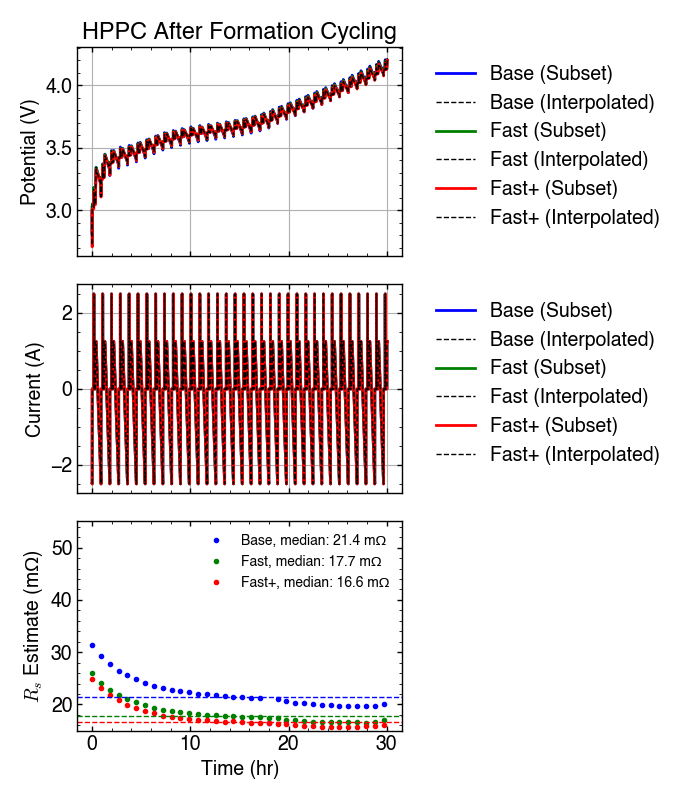

In [32]:
Rs_estimate1, idx1 = calculate_resistance_estimates(subset_df1['Potential (V)'].values, subset_df1['Current (A)'].values, subset_df1['Time (s)'].values)
Rs_estimate3, idx3 = calculate_resistance_estimates(subset_df3['Potential (V)'].values, subset_df3['Current (A)'].values, subset_df3['Time (s)'].values)
Rs_estimate4, idx4 = calculate_resistance_estimates(subset_df4['Potential (V)'].values, subset_df4['Current (A)'].values, subset_df4['Time (s)'].values)

fig, axs = plt.subplots(3, 1, figsize=(7, 8), sharex=True)

axs[0].set_title('HPPC After Formation Cycling')
axs[0].plot(subset_df1['Time (s)']/3600, subset_df1['Potential (V)'], label='Base (Subset)', linewidth=2, linestyle='-', color='blue')
axs[0].plot(time_interp1/3600, voltage_interp1, label='Base (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].plot(subset_df3['Time (s)']/3600, subset_df3['Potential (V)'], label='Fast (Subset)', linewidth=2, linestyle='-', color='green')
axs[0].plot(time_interp3/3600, voltage_interp3, label='Fast (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].plot(subset_df4['Time (s)']/3600, subset_df4['Potential (V)'], label='Fast+ (Subset)', linewidth=2, linestyle='-', color='red')
axs[0].plot(time_interp4/3600, voltage_interp4, label='Fast+ (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].set_ylabel('Potential (V)')
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Second subplot for Current
axs[1].plot(subset_df1['Time (s)']/3600, subset_df1['Current (A)'], label='Base (Subset)', linewidth=2, linestyle='-', color='blue')
axs[1].plot(time_interp1/3600, current_interp1, label='Base (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].plot(subset_df3['Time (s)']/3600, subset_df3['Current (A)'], label='Fast (Subset)', linewidth=2, linestyle='-', color='green')
axs[1].plot(time_interp3/3600, current_interp3, label='Fast (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].plot(subset_df4['Time (s)']/3600, subset_df4['Current (A)'], label='Fast+ (Subset)', linewidth=2, linestyle='-', color='red')
axs[1].plot(time_interp4/3600, current_interp4, label='Fast+ (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].set_ylabel('Current (A)')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

trs1 = subset_df1['Time (s)'].iloc[idx1]
trs3 = subset_df3['Time (s)'].iloc[idx3]
trs4 = subset_df4['Time (s)'].iloc[idx4]
axs[2].plot((trs1 - trs1.iloc[0])/3600, Rs_estimate1*1e3, label=f'Base, median: {np.nanmedian(Rs_estimate1*1e3):.1f} mΩ', color='blue', marker='o', markersize=3, linestyle='None')
axs[2].plot((trs3 - trs3.iloc[0])/3600, Rs_estimate3*1e3, label=f'Fast, median: {np.nanmedian(Rs_estimate3*1e3):.1f} mΩ', color='green', marker='o', markersize=3, linestyle='None')
axs[2].plot((trs4 - trs4.iloc[0])/3600, Rs_estimate4*1e3, label=f'Fast+, median: {np.nanmedian(Rs_estimate4*1e3):.1f} mΩ', color='red', marker='o', markersize=3, linestyle='None')
axs[2].axhline(np.nanmedian(Rs_estimate1)*1e3, color='blue', linestyle='--', linewidth=1, label='')
axs[2].axhline(np.nanmedian(Rs_estimate3)*1e3, color='green', linestyle='--', linewidth=1, label='')
axs[2].axhline(np.nanmedian(Rs_estimate4)*1e3, color='red', linestyle='--', linewidth=1, label='')
# axs[2].annotate(f'Base median: {np.nanmedian(Rs_estimate1*1e3):.1f} mΩ', 
#                 xy=(0.15, 0.90), xycoords='axes fraction', fontsize=10)
# axs[2].annotate(f'Fast median: {np.nanmedian(Rs_estimate3*1e3):.1f} mΩ',
#                 xy=(0.15, 0.83), xycoords='axes fraction', fontsize=10)
# axs[2].annotate(f'Fast+ median: {np.nanmedian(Rs_estimate4*1e3):.1f} mΩ',
#                 xy=(0.15, 0.76), xycoords='axes fraction', fontsize=10)
axs[2].set_xlabel('Time (hr)')
axs[2].grid(False)
axs[2].set_ylim(15,55)
axs[2].set_ylabel('$R_s$ Estimate (mΩ)')
axs[2].legend(loc='upper right', fontsize=10)
# axs[2].set_xlim((0, 5000))?

## Second HPPC (after formation aging)

In [28]:
si1_hppc = [12, 13, 14, 15, 16, 17]
si2_hppc = [14, 15, 16, 17, 18, 19]
si3_hppc = [14, 15, 16, 17, 18, 19]

# Subset df1, df3, and df4 using si1_hppc, si2_hppc, and si3_hppc to filter on 'Step Index'
df1_one = df1[(df1['Timestamp'] > pd.to_datetime('2022-09-15')) & (df1['Timestamp'] < pd.to_datetime('2022-10-01'))]
df3_one = df3[(df3['Timestamp'] > pd.to_datetime('2022-09-15')) & (df3['Timestamp'] < pd.to_datetime('2022-10-01'))]
df4_one = df4[(df4['Timestamp'] > pd.to_datetime('2022-09-15')) & (df4['Timestamp'] < pd.to_datetime('2022-10-01'))]

subset_df1 = df1_one[df1_one['Step Index'].isin(si1_hppc)]
subset_df3 = df3_one[df3_one['Step Index'].isin(si2_hppc)]
subset_df4 = df4_one[df4_one['Step Index'].isin(si3_hppc)]

subset_df1['Time (s)'] = (subset_df1['Timestamp'] - subset_df1['Timestamp'].iloc[0]).dt.total_seconds()
subset_df3['Time (s)'] = (subset_df3['Timestamp'] - subset_df3['Timestamp'].iloc[0]).dt.total_seconds()
subset_df4['Time (s)'] = (subset_df4['Timestamp'] - subset_df4['Timestamp'].iloc[0]).dt.total_seconds()

# Define a 0.1s grid for interpolation
time_grid = np.arange(0, max(subset_df1['Time (s)'].max(), subset_df3['Time (s)'].max(), subset_df4['Time (s)'].max()), 0.1)

# Interpolate for subset_df1
interp_voltage1 = interp1d(subset_df1['Time (s)'], subset_df1['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current1 = interp1d(subset_df1['Time (s)'], subset_df1['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp1 = time_grid
voltage_interp1 = interp_voltage1(time_interp1)
current_interp1 = interp_current1(time_interp1)

# Interpolate for subset_df3
interp_voltage3 = interp1d(subset_df3['Time (s)'], subset_df3['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current3 = interp1d(subset_df3['Time (s)'], subset_df3['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp3 = time_grid
voltage_interp3 = interp_voltage3(time_interp3)
current_interp3 = interp_current3(time_interp3)

# Interpolate for subset_df4
interp_voltage4 = interp1d(subset_df4['Time (s)'], subset_df4['Potential (V)'], kind='linear', fill_value="extrapolate")
interp_current4 = interp1d(subset_df4['Time (s)'], subset_df4['Current (A)'], kind='linear', fill_value="extrapolate")
time_interp4 = time_grid
voltage_interp4 = interp_voltage4(time_interp4)
current_interp4 = interp_current4(time_interp4)


/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_67573/3191092511.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df1['Time (s)'] = (subset_df1['Timestamp'] - subset_df1['Timestamp'].iloc[0]).dt.total_seconds()
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn/T/ipykernel_67573/3191092511.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_df3['Time (s)'] = (subset_df3['Timestamp'] - subset_df3['Timestamp'].iloc[0]).dt.total_seconds()
/var/folders/33/qps6sqvx73v5zk2zp2wxxgpm0000gn

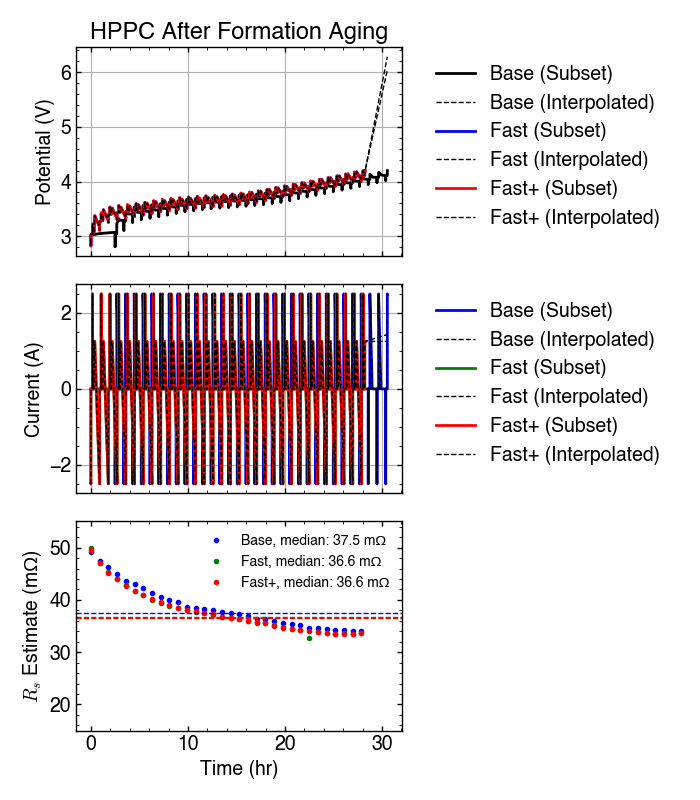

In [29]:
Rs_estimate1, idx1 = calculate_resistance_estimates(subset_df1['Potential (V)'].values, subset_df1['Current (A)'].values, subset_df1['Time (s)'].values)
Rs_estimate3, idx3 = calculate_resistance_estimates(subset_df3['Potential (V)'].values, subset_df3['Current (A)'].values, subset_df3['Time (s)'].values)
Rs_estimate4, idx4 = calculate_resistance_estimates(subset_df4['Potential (V)'].values, subset_df4['Current (A)'].values, subset_df4['Time (s)'].values)

fig, axs = plt.subplots(3, 1, figsize=(7, 8), sharex=True)

axs[0].set_title('HPPC After Formation Aging')
axs[0].plot(subset_df1['Time (s)']/3600, subset_df1['Potential (V)'], label='Base (Subset)', linewidth=2, linestyle='-', color='k')
axs[0].plot(time_interp1/3600, voltage_interp1, label='Base (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].plot(subset_df3['Time (s)']/3600, subset_df3['Potential (V)'], label='Fast (Subset)', linewidth=2, linestyle='-', color='b')
axs[0].plot(time_interp3/3600, voltage_interp3, label='Fast (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].plot(subset_df4['Time (s)']/3600, subset_df4['Potential (V)'], label='Fast+ (Subset)', linewidth=2, linestyle='-', color='red')
axs[0].plot(time_interp4/3600, voltage_interp4, label='Fast+ (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[0].set_ylabel('Potential (V)')
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Second subplot for Current
axs[1].plot(subset_df1['Time (s)']/3600, subset_df1['Current (A)'], label='Base (Subset)', linewidth=2, linestyle='-', color='blue')
axs[1].plot(time_interp1/3600, current_interp1, label='Base (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].plot(subset_df3['Time (s)']/3600, subset_df3['Current (A)'], label='Fast (Subset)', linewidth=2, linestyle='-', color='green')
axs[1].plot(time_interp3/3600, current_interp3, label='Fast (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].plot(subset_df4['Time (s)']/3600, subset_df4['Current (A)'], label='Fast+ (Subset)', linewidth=2, linestyle='-', color='red')
axs[1].plot(time_interp4/3600, current_interp4, label='Fast+ (Interpolated)', linestyle='--', color='k', linewidth=1)
axs[1].set_ylabel('Current (A)')
axs[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

trs1 = subset_df1['Time (s)'].iloc[idx1]
trs3 = subset_df3['Time (s)'].iloc[idx3]
trs4 = subset_df4['Time (s)'].iloc[idx4]
axs[2].plot((trs1 - trs1.iloc[0])/3600, Rs_estimate1*1e3, label=f'Base, median: {np.nanmedian(Rs_estimate1*1e3):.1f} mΩ', color='blue', marker='o', markersize=3, linestyle='None')
axs[2].plot((trs3 - trs3.iloc[0])/3600, Rs_estimate3*1e3, label=f'Fast, median: {np.nanmedian(Rs_estimate3*1e3):.1f} mΩ', color='green', marker='o', markersize=3, linestyle='None')
axs[2].plot((trs4 - trs4.iloc[0])/3600, Rs_estimate4*1e3, label=f'Fast+, median: {np.nanmedian(Rs_estimate4*1e3):.1f} mΩ', color='red', marker='o', markersize=3, linestyle='None')
axs[2].axhline(np.nanmedian(Rs_estimate1)*1e3, color='blue', linestyle='--', linewidth=1, label='')
axs[2].axhline(np.nanmedian(Rs_estimate3)*1e3, color='green', linestyle='--', linewidth=1, label='')
axs[2].axhline(np.nanmedian(Rs_estimate4)*1e3, color='red', linestyle='--', linewidth=1, label='')
# axs[2].annotate(f'Base median: {np.nanmedian(Rs_estimate1*1e3):.1f} mΩ', 
#                 xy=(0.15, 0.90), xycoords='axes fraction', fontsize=10)
# axs[2].annotate(f'Fast median: {np.nanmedian(Rs_estimate3*1e3):.1f} mΩ',
#                 xy=(0.15, 0.83), xycoords='axes fraction', fontsize=10)
# axs[2].annotate(f'Fast+ median: {np.nanmedian(Rs_estimate4*1e3):.1f} mΩ',
#                 xy=(0.15, 0.76), xycoords='axes fraction', fontsize=10)
axs[2].set_xlabel('Time (hr)')
axs[2].grid(False)
axs[2].set_ylim(15,55)
axs[2].set_ylabel('$R_s$ Estimate (mΩ)')
axs[2].legend(loc='upper right', fontsize=10)
# axs[2].set_xlim((0, 5000))?

plt.show()

# Manually extract the capacities from inspecting the plots

In [17]:
f1_capd1 = 2.527
f2_capd1 = 2.540
f3_capd1 = 2.536
f1_capd2 = 2.445
f2_capd2 = 2.461
f3_capd2 = 2.461
f1_capd3 = 2.275
f2_capd3 = 2.315
f3_capd3 = 2.318


# Summarize the results

In [18]:
data = {
    'Q1 [Ah]': [f1_capd1, f2_capd1, f3_capd1],
    'Q2 [Ah]': [f1_capd2, f2_capd2, f3_capd2],
    'Q3 [Ah]': [f1_capd3, f2_capd3, f3_capd3],
    'Rs [Ohms]': [np.nanmedian(Rs_estimate1), np.nanmedian(Rs_estimate3), np.nanmedian(Rs_estimate4)]
}
labels = ['Base', 'Fast', 'Fast+']

df_summary = pd.DataFrame(data, index=labels)
df_summary

,Q1 [Ah],Q2 [Ah],Q3 [Ah],Rs [Ohms]
Base,2.527,2.445,2.275,0.037517
Fast,2.540,2.461,2.315,0.036642
Fast+,2.536,2.461,2.318,0.036614


# Now take a closer look at all of the data

Including the cycling data!

In [19]:
expt1, df1 = ioutils.fetch_experimental_data(152064, to_include_cycling=True)
expt3, df3 = ioutils.fetch_experimental_data(152071, to_include_cycling=True)
expt4, df4 = ioutils.fetch_experimental_data(152098, to_include_cycling=True)

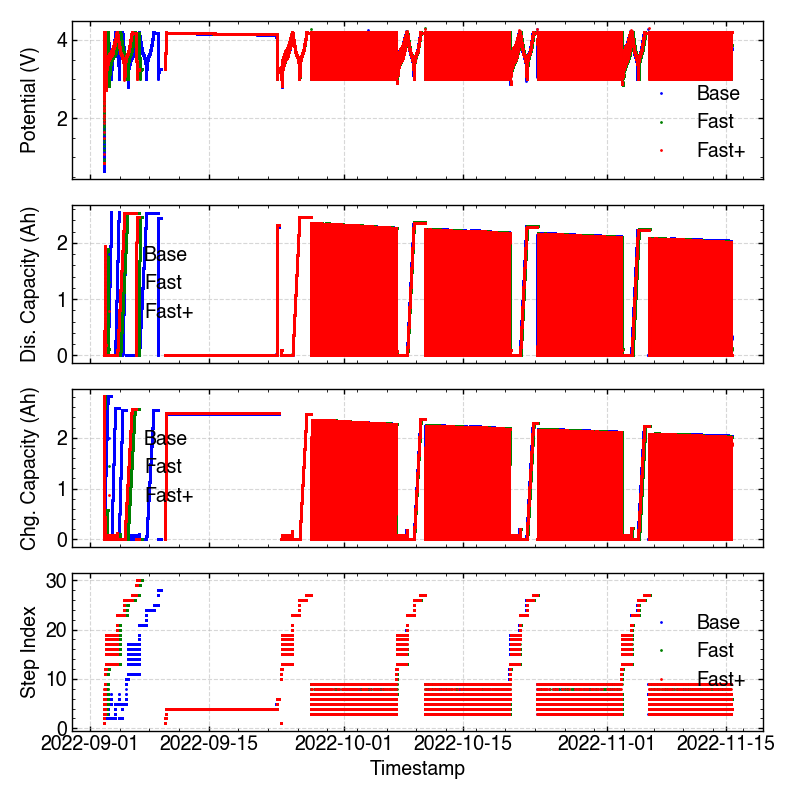

In [20]:
fig, axs = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

# First subplot
axs[0].plot(df1['Timestamp'], df1['Potential (V)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[0].plot(df3['Timestamp'], df3['Potential (V)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[0].plot(df4['Timestamp'], df4['Potential (V)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[0].set_ylabel('Potential (V)')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend()

# Second subplot
axs[1].plot(df1['Timestamp'], df1['Discharge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[1].plot(df3['Timestamp'], df3['Discharge Capacity (Ah)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[1].plot(df4['Timestamp'], df4['Discharge Capacity (Ah)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[1].set_ylabel('Dis. Capacity (Ah)')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend()

# Third subplot
axs[2].plot(df1['Timestamp'], df1['Charge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[2].plot(df3['Timestamp'], df3['Charge Capacity (Ah)'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[2].plot(df4['Timestamp'], df4['Charge Capacity (Ah)'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[2].set_ylabel('Chg. Capacity (Ah)')
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].legend()

# Fourth subplot
axs[3].plot(df1['Timestamp'], df1['Step Index'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[3].plot(df3['Timestamp'], df3['Step Index'], label='Fast', color='green', ls='none', marker='o', markersize=1)
axs[3].plot(df4['Timestamp'], df4['Step Index'], label='Fast+', color='red', ls='none', marker='o', markersize=1)
axs[3].set_ylabel('Step Index')
axs[3].set_xlabel('Timestamp')
axs[3].grid(True, linestyle='--', alpha=0.5)
axs[3].legend()


# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.show()


# Cycle life

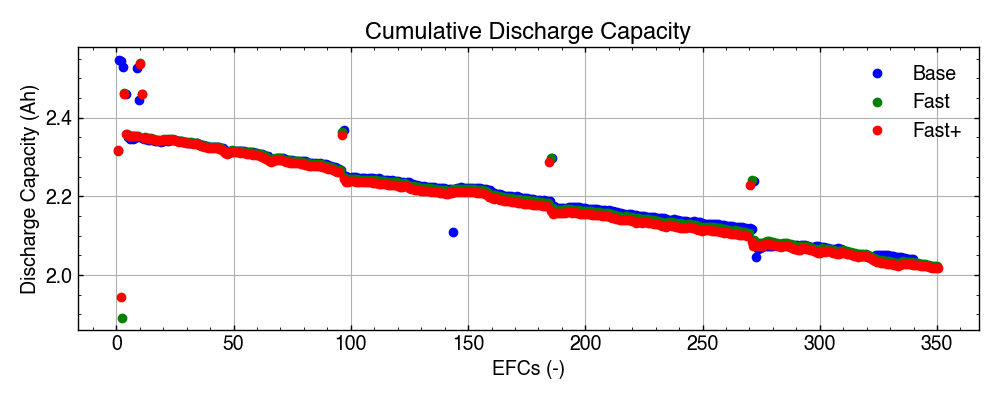

In [21]:
NOM_CAP = 2.5

df1_agg = df1.groupby('Cycle Number')['Discharge Capacity (Ah)'].max()
df3_agg = df3.groupby('Cycle Number')['Discharge Capacity (Ah)'].max()
df4_agg = df4.groupby('Cycle Number')['Discharge Capacity (Ah)'].max()

df1_agg_cumsum = df1_agg.cumsum()/NOM_CAP
df3_agg_cumsum = df3_agg.cumsum()/NOM_CAP
df4_agg_cumsum = df4_agg.cumsum()/NOM_CAP

df1_agg[df1_agg.values < 1] = np.nan
df3_agg[df3_agg.values < 1] = np.nan
df4_agg[df4_agg.values < 1] = np.nan

fig, axs = plt.subplots(1, 1, figsize=(10, 4), sharex=True)

# Aggregate and plot for df1
axs.plot(df1_agg_cumsum.values, df1_agg.values, label='Base', color='blue', marker='o', linestyle='')
axs.plot(df3_agg_cumsum.values, df3_agg.values, label='Fast', color='green', marker='o', linestyle='')
axs.plot(df4_agg_cumsum.values, df4_agg.values, label='Fast+', color='red', marker='o', linestyle='')
axs.set_ylabel('Discharge Capacity (Ah)')
axs.set_xlabel('EFCs (-)')
axs.set_title('Cumulative Discharge Capacity')
axs.grid(True)
axs.legend()

plt.tight_layout()
plt.show()

# Coulombic efficiency during formation

              Charge Capacity (Ah)  Discharge Capacity (Ah)  \
Cycle Number                                                  
1                         2.814124                 2.546351   
2                         2.578596                 2.544815   
3                         2.554039                 2.529850   

              Coulombic Efficiency  
Cycle Number                        
1                         0.904847  
2                         0.986900  
3                         0.990529  


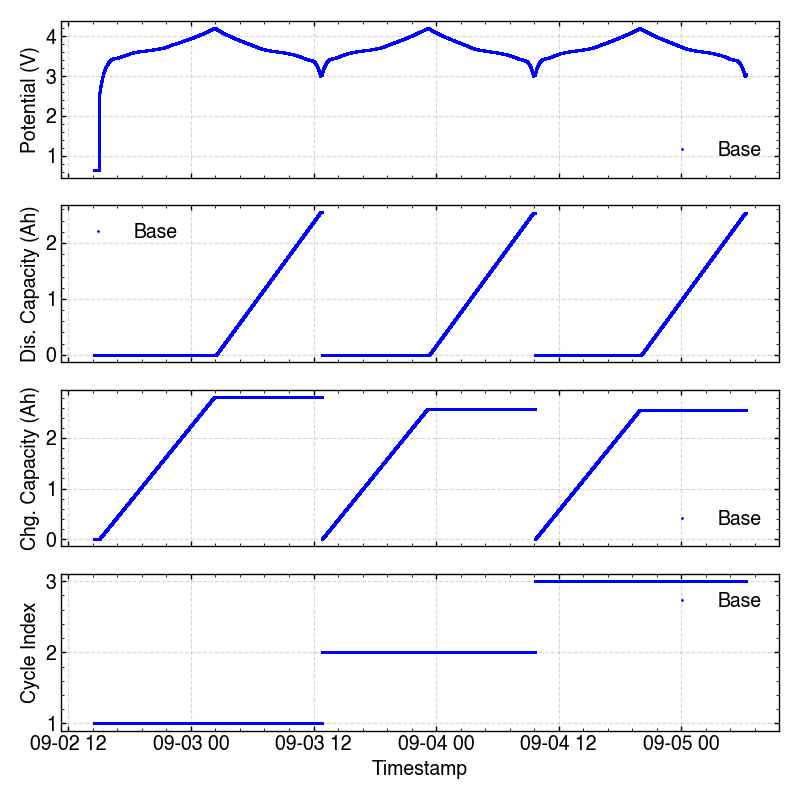

In [22]:
df1lim = df1[df1['Cycle Number'] <= 3]
df1lim = df1lim[df1lim['Timestamp'] < '2022-09-06 00:00:00']

df1lim_agg = df1lim.groupby('Cycle Number').agg({'Charge Capacity (Ah)': 'max', 'Discharge Capacity (Ah)': 'max'})
df1lim_agg['Coulombic Efficiency'] = df1lim_agg['Discharge Capacity (Ah)'] / df1lim_agg['Charge Capacity (Ah)']
print(df1lim_agg)

fig, axs = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

# First subplot: Potential (V) vs. Timestamp
axs[0].plot(df1lim['Timestamp'], df1lim['Potential (V)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[0].set_ylabel('Potential (V)')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend()

# Second subplot: Discharge Capacity (Ah) vs. Timestamp
axs[1].plot(df1lim['Timestamp'], df1lim['Discharge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[1].set_ylabel('Dis. Capacity (Ah)')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend()

# Third subplot: Charge Capacity (Ah) vs. Timestamp
axs[2].plot(df1lim['Timestamp'], df1lim['Charge Capacity (Ah)'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[2].set_ylabel('Chg. Capacity (Ah)')
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].legend()

# Fourth subplot: Step Index vs. Timestamp
axs[3].plot(df1lim['Timestamp'], df1lim['Cycle Number'], label='Base', color='blue', ls='none', marker='o', markersize=1)
axs[3].set_ylabel('Cycle Index')
axs[3].set_xlabel('Timestamp')
axs[3].grid(True, linestyle='--', alpha=0.5)
axs[3].legend()

# Align y-axis labels
fig.align_ylabels(axs)
plt.tight_layout()
plt.show()

# Expansion Data

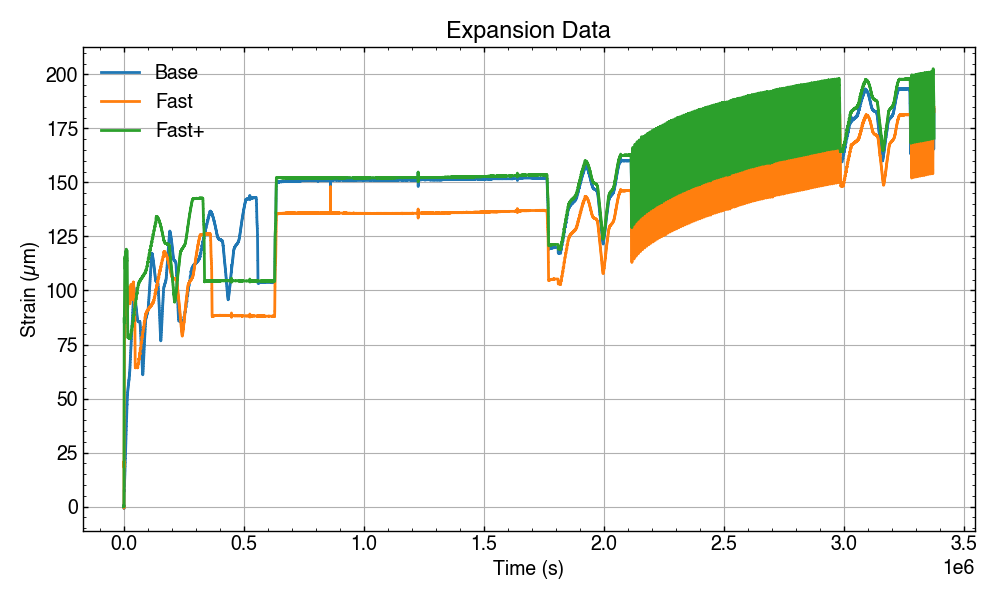

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(expt1['daq_time'], expt1['daq_strain'], label='Base')
ax.plot(expt3['daq_time'], expt3['daq_strain'], label='Fast')
ax.plot(expt4['daq_time'], expt4['daq_strain'], label='Fast+')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Strain (µm)')
ax.set_title('Expansion Data')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

NameError: name 'expt2' is not defined

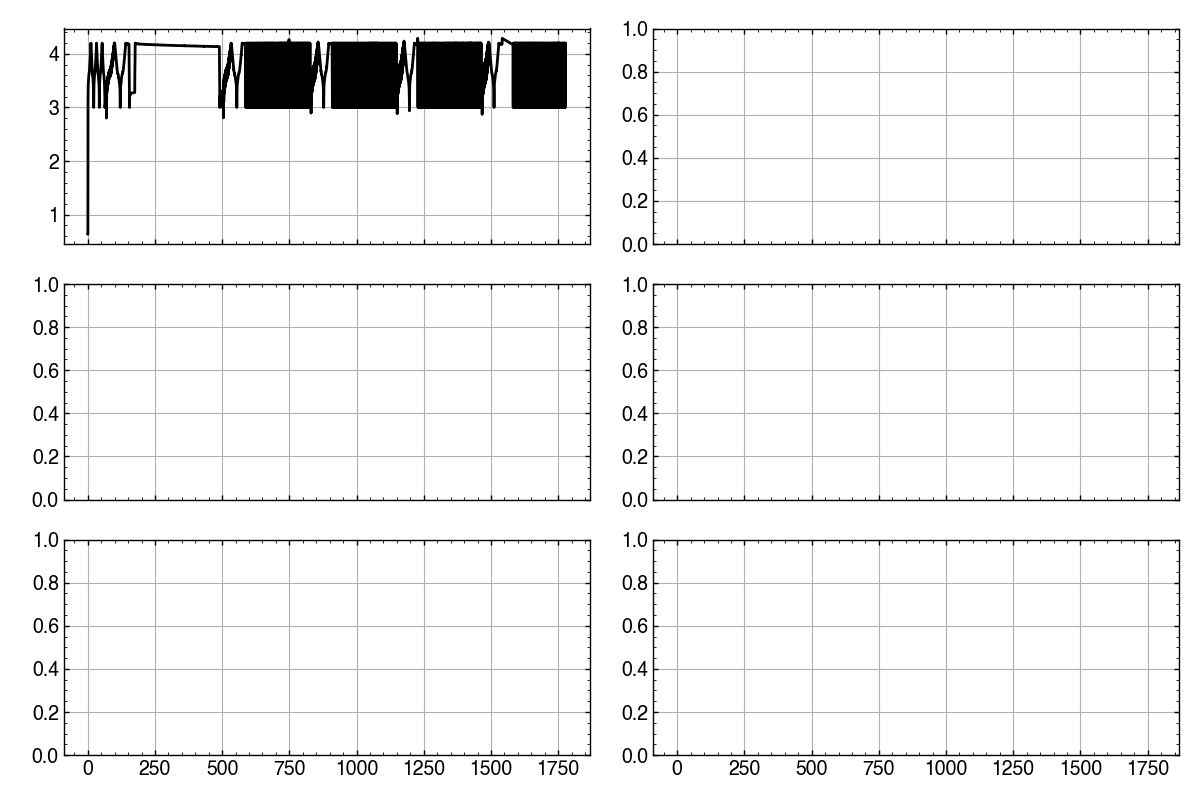

In [24]:
fig, axs = plt.subplots(3, 2, figsize=(12, 8), sharex=True)

axs[0,0].plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], label='Baseline (Cell 1)', color='black')
axs[0,0].plot(expt2['arbin_time']/3600, expt2['arbin_voltage'], label='Baseline (Cell 2)', color='black', ls=':')
axs[0,0].grid(False)
axs[0,0].legend()
axs[0,0].set_ylabel('Potential (V)')

axs[1,0].plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], label='Fast', color='blue')
axs[1,0].grid(False)
axs[1,0].legend()
axs[1,0].set_ylabel('Potential (V)')

axs[2,0].plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], label='Fast+', color='red')
axs[2,0].set_ylabel('Potential (V)')
axs[2,0].legend()
axs[2,0].grid(False)

axs[2,0].set_xlim((-0.1, 600))
axs[2,0].set_xlabel('Time (hrs)')

# Second subplot: Strain vs. Time
axs[0,1].plot(expt1['daq_time']/3600, expt1['daq_strain'], label='Baseline (Cell 1)', color='black')
axs[0,1].plot(expt2['daq_time']/3600, expt2['daq_strain'], label='Baseline (Cell 2)', color='black', ls=':')
axs[0,1].grid(False)
axs[0,1].legend()
axs[0,1].set_ylabel('Strain (µm)')

axs[1,1].plot(expt3['daq_time']/3600, expt3['daq_strain'], label='Fast', color='blue')
axs[1,1].grid(False)
axs[1,1].legend()
axs[1,1].set_ylabel('Strain (µm)')

axs[2,1].plot(expt4['daq_time']/3600, expt4['daq_strain'], label='Fast+', color='red')
axs[2,1].set_ylabel('Strain (µm)')
axs[2,1].legend()
axs[2,1].grid(False)
axs[2,1].set_xlabel('Time (hrs)')

axs[2,1].set_xlim((-0.1, 450))

plt.tight_layout()
plt.show()

In [ ]:
from src import cellsim as cellsim

%autoreload
Ichg = 2.5/10  # A
Idch = -2.5/10 # A
Icv = 2.5/20   # A

vmax = 4.2
vmin = 3.0

cell = cellsim.Cell()
cell.load_config('params/default.yaml')
tag = cell.get_tag()

# sim = cellsim.Simulation(cell, 520*3600)
sim1 = cellsim.Simulation(cell, 70*24*3600)

# Formation
sim1.run_rest(1, rest_time_hrs=0.5)
sim1.run_chg_cccv(2, 2.5/10, 2.5/20, 4.2)
sim1.run_rest(2, rest_time_hrs=1/6) 
sim1.run_dch_cccv(2, -2.5/10, -2.5/10, 3.0)
sim1.run_rest(2, rest_time_hrs=1/6) 
sim1.run_chg_cccv(3, 2.5/10, 2.5/20, 4.2)
sim1.run_rest(3, rest_time_hrs=1/6) 
sim1.run_dch_cccv(3, -2.5/10, -2.5/10, 3.0)
sim1.run_rest(3, rest_time_hrs=1/6) 
sim1.run_chg_cccv(4, 2.5/10, 2.5/20, 4.2)
sim1.run_rest(4, rest_time_hrs=1/6) 
sim1.run_dch_cccv(4, -2.5/10, 0.05, 3.0)
sim1.run_rest(4, rest_time_hrs=1/6) 
sim1.run_dch_cccv(4, -2.5/10, 0.05, 3.0)
sim1.run_rest(4, rest_time_hrs=6)

# RPT
sim1.run_chg_cccv(5, +2.5/30, +2.5/30, vmax) # Approximate HPPC Pulse Charge
sim1.run_dch_cccv(5, -2.5/20, Icv, vmin)
sim1.run_chg_cccv(6, +2.5/20, Icv, vmax)
sim1.run_rest(6, rest_time_hrs=12)
sim1.run_dch_cccv(6, -2.5/2, -2.5/2, vmin)
sim1.run_rest(6, rest_time_hrs=20)

# Formation Aging
sim1.run_chg_cccv(7, 2.5/2, 0.05, vmax)
sim1.run_rest(7, rest_time_hrs=13*24) # 13 days rest
sim1.run_dch_cccv(7, -2.5/2, -2.5/2, vmin)
sim1.run_rest(7, rest_time_hrs=12) # 12 hours rest

# RPT
sim1.run_chg_cccv(8, +2.5/30, +2.5/30, vmax) # Approximate HPPC Pulse Charge
sim1.run_dch_cccv(8, -2.5/20, Icv, vmin)
sim1.run_chg_cccv(8, +2.5/20, Icv, vmax)
sim1.run_rest(    9, rest_time_hrs=12)
sim1.run_dch_cccv(9, -2.5/2, -2.5/2, vmin)

# Cycling
cycles_to_rpt = 100
for i in np.arange(10, 10 + cycles_to_rpt + 1):
    sim1.run_chg_cccv(i, 2.5, 0.125, vmax)
    sim1.run_rest(i, rest_time_hrs=1/6)
    sim1.run_dch_cccv(i, -2.5, -2.5, vmin)
    sim1.run_rest(i, rest_time_hrs=1/6)

# RPT
sim1.run_chg_cccv(111, +2.5/30, +2.5/30, vmax) # Approximate HPPC Pulse Charge
sim1.run_dch_cccv(111, -2.5/20, Icv, vmin)
sim1.run_chg_cccv(111, +2.5/20, Icv, vmax)
sim1.run_rest(112, rest_time_hrs=12)
sim1.run_dch_cccv(112, -2.5/2, -2.5/2, vmin)

# Cycling
for i in np.arange(113, 113 + cycles_to_rpt + 1):
    sim1.run_chg_cccv(i, 2.5, 0.125, vmax)
    sim1.run_rest(i, rest_time_hrs=1/6)
    sim1.run_dch_cccv(i, -2.5, -2.5, vmin)
    sim1.run_rest(i, rest_time_hrs=1/6)

# RPT
sim1.run_chg_cccv(214, +2.5/30, +2.5/30, vmax) # Approximate HPPC Pulse Charge
sim1.run_dch_cccv(214, -2.5/20, Icv, vmin)
sim1.run_chg_cccv(215, +2.5/20, Icv, vmax)
sim1.run_rest(    215, rest_time_hrs=12)
sim1.run_dch_cccv(215, -2.5/2, -2.5/2, vmin)

# Cycling
for i in np.arange(216, 216 + cycles_to_rpt + 1):
    sim1.run_chg_cccv(i, 2.5, 0.125, vmax)
    sim1.run_rest(i, rest_time_hrs=1/6)
    sim1.run_dch_cccv(i, -2.5, -2.5, vmin)
    sim1.run_rest(i, rest_time_hrs=1/6)

# RPT
sim1.run_chg_cccv(317, +2.5/30, +2.5/30, vmax) # Approximate HPPC Pulse Charge
sim1.run_dch_cccv(317, -2.5/20, Icv, vmin)
sim1.run_chg_cccv(318, +2.5/20, Icv, vmax)
sim1.run_rest(    318, rest_time_hrs=12)
sim1.run_dch_cccv(318, -2.5/2, -2.5/2, vmin)

df_sim1 = sim1.get_results()

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

# First subplot: Time vs Voltage
axs[0].plot(df_sim1['t']/3600/24, df_sim1['vt'], label='Simulated', color='blue')
axs[0].plot(expt1['arbin_time']/3600/24, expt1['arbin_voltage'], label='Measured', color='black')
axs[0].set_ylabel('Voltage (V)')
axs[0].grid(False)

axs[1].plot(df_sim1['t']/3600/24, df_sim1['i_app'], label='Simulated', color='blue')
axs[1].plot(expt1['arbin_time']/3600/24, expt1['arbin_current'], label='Measured', color='black')
axs[1].set_ylabel('Current (A)')
axs[1].grid(False)

# Second subplot: Time vs Expansion
axs[2].plot(df_sim1['t']/3600/24, 1e6*df_sim1['expansion'], label='Simulated', color='blue')
axs[2].plot(expt1['daq_time']/3600/24, expt1['daq_strain'], label='Measured', color='black')
axs[2].set_ylabel('Strain (µm)')
axs[2].grid(False)

# Third subplot: Time vs R_sei
axs[3].plot(df_sim1['t']/3600/24, 1e3*df_sim1['R_sei'], label='Simulated R_sei', color='blue')
axs[3].set_xlabel('Time (days)')
axs[3].set_ylabel('R (mOhm)')
axs[3].grid(False)

plt.tight_layout()
plt.show()